In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from utils import concatenate_results_genre, concatenate_results_random, concatenate_results_maetest

## Load all the relevant results

In [2]:
path_results_IRMs = '../results/IRMs'
path_results_MIMs = '../results/MIMs'

genre_all_IRMs = f'{path_results_IRMs}/1_genre_all.csv'
genre_all_MIMs = f'{path_results_MIMs}/1_genre_all.csv'

if not os.path.isfile(genre_all_IRMs):
    concatenate_results_genre(genre_all_IRMs, path_results=path_results_IRMs)
if not os.path.isfile(genre_all_MIMs):
    concatenate_results_genre(genre_all_MIMs, path_results=path_results_MIMs)

df_genre_IRMs = pd.read_csv(genre_all_IRMs)
df_genre_MIMs = pd.read_csv(genre_all_MIMs)

df_genre_IRMs['original_order'] = range(len(df_genre_IRMs)) # to keep the original order
df_genre = pd.merge(df_genre_IRMs, df_genre_MIMs, on=['model', 'genre', 'midiset', 'audioset', 'piece_id'], how='outer')
df_genre = df_genre.sort_values(by='original_order').drop(columns=['original_order']).reset_index(drop=True)
df_genre_IRMs = df_genre_IRMs.drop(columns=['original_order']); # cleanup

random_all_IRMs = f'{path_results_IRMs}/2_random_all.csv'
random_all_MIMs = f'{path_results_MIMs}/2_random_all.csv'

if not os.path.isfile(random_all_IRMs):
    concatenate_results_random(random_all_IRMs, path_results=path_results_IRMs)
if not os.path.isfile(random_all_MIMs):
    concatenate_results_random(random_all_MIMs, path_results=path_results_MIMs)

df_random_IRMs = pd.read_csv(random_all_IRMs)
df_random_MIMs = pd.read_csv(random_all_MIMs)

df_random_IRMs['original_order'] = range(len(df_random_IRMs)) # to keep the original order
df_random = pd.merge(df_random_IRMs, df_random_MIMs, on=['model', 'polyphony', 'dynamics', 'midiset', 'audioset', 'piece_id'], how='outer')
df_random = df_random.sort_values(by='original_order').drop(columns=['original_order']).reset_index(drop=True)
df_random_IRMs = df_random_IRMs.drop(columns=['original_order']); # cleanup

maetest_all_IRMs = f'{path_results_IRMs}/3_maetest_all.csv'
maetest_all_MIMs = f'{path_results_MIMs}/3_maetest_all.csv'

if not os.path.isfile(maetest_all_IRMs):
    concatenate_results_maetest(maetest_all_IRMs, path_results=path_results_IRMs)
if not os.path.isfile(maetest_all_MIMs):
    concatenate_results_maetest(maetest_all_MIMs, path_results=path_results_MIMs)

df_maetest_IRMs = pd.read_csv(maetest_all_IRMs)
df_maetest_MIMs = pd.read_csv(maetest_all_MIMs)

df_maetest_IRMs['original_order'] = range(len(df_maetest_IRMs)) # to keep the original order
df_maetest = pd.merge(df_maetest_IRMs, df_maetest_MIMs, on=['model', 'midiset', 'audioset', 'piece_id'], how='outer')
df_maetest = df_maetest.sort_values(by='original_order').drop(columns=['original_order']).reset_index(drop=True)
df_maetest_IRMs = df_maetest_IRMs.drop(columns=['original_order']); # cleanup

# extract set of f-score metric columns
columns_fscore = [col for col in df_random_IRMs.columns if col.startswith('f_')]

# extract sets of metrics columns
columns_articulation = [col for col in df_random_MIMs.columns if col.endswith('_kor_corr_64')]
columns_timing = [col for col in df_random_MIMs.columns if col.endswith('_ioi_corr')]
columns_harmony = [col for col in df_random_MIMs.columns if col.startswith('cloud_') or col.startswith('tensile_')]
columns_dynamics = ['dyn_corr']
columns_mims_all = columns_articulation + columns_timing + columns_harmony + columns_dynamics

# set ordering of genres and models
genres_order = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
models_order = ['OaF', 'Kong', 'T5', 'Toyama', 'Edwards']

columns_all = columns_fscore + columns_mims_all

markers = {'OaF': 'o', 'Kong': '*', 'T5': 's', 'Toyama': 'D', 'Edwards': '^'} # unused for now.. applying seaborn's default sequence of markers
err_kws_bar = {'alpha': 0.5} #{'color': 'black', 'linewidth': 2.0, 'alpha': 0.5}

# Metrics reported in the respective papers
papers_f1_maestro_test = {
    'f_frame': {
        'OaF': 0.9015, 'Kong': 0.8962, 'T5': None, 'Toyama': 0.9324, 'Edwards': None,},
    'f_note_on': {
        'OaF': 0.9532, 'Kong': 0.9672, 'T5': 0.9601, 'Toyama': 0.9744, 'Edwards': 0.9660,},
    'f_note_on_off': {
        'OaF': 0.8050, 'Kong': 0.8247, 'T5': 0.8394, 'Toyama': 0.9053, 'Edwards': None,},
    'f_note_on_off_vel': {
        'OaF': 0.7754, 'Kong': 0.8092, 'T5': 0.8275, 'Toyama': 0.8948, 'Edwards': None,},
}

df_maetest_papers = pd.DataFrame(papers_f1_maestro_test)
df_maetest_papers.index.name = 'model'
df_maetest_papers.insert(0, 'audioset', 'paper')
df_maetest_papers.reset_index(inplace=True, drop=False)

# our measurements: IRMs
df_maetest_means_IRMs = df_maetest_IRMs.groupby(['model', 'audioset'])[columns_fscore].mean().reset_index()

# combine IRMs with papers
df_maetest_means_all = pd.concat([df_maetest_means_IRMs, df_maetest_papers])
df_maetest_means_all['model'] = pd.Categorical(df_maetest_means_all['model'], categories=models_order, ordered=True)
df_maetest_means_all.sort_values(['model', 'audioset'], inplace=True)
df_maetest_means_all.reset_index(drop=True, inplace=True)

# our measurements: MIMs
df_maetest_means_MIMs = df_maetest_MIMs.groupby(['model', 'audioset'])[columns_mims_all].mean().reset_index()
df_maetest_means_MIMs['model'] = pd.Categorical(df_maetest_means_MIMs['model'], categories=models_order, ordered=True)
df_maetest_means_MIMs.sort_values(['model', 'audioset'], inplace=True)
df_maetest_means_MIMs.reset_index(drop=True, inplace=True)

# add MIMs to IRMs and paper results
df_maetest_means_all = pd.merge(df_maetest_means_all, df_maetest_means_MIMs, on=['model', 'audioset'], how='outer')

df_maetest_IRMs_mae = df_maetest_IRMs[df_maetest_IRMs['audioset'] == 'maestro']
df_maetest_IRMs_dk = df_maetest_IRMs[df_maetest_IRMs['audioset'] == 'disklavier']
all_subsets_IRMs = [df_maetest_IRMs_mae, df_maetest_IRMs_dk, df_genre_IRMs, df_random_IRMs]

df_maetest_MIMs_mae = df_maetest_MIMs[df_maetest_MIMs['audioset'] == 'maestro']
df_maetest_MIMs_dk = df_maetest_MIMs[df_maetest_MIMs['audioset'] == 'disklavier']
all_subsets_MIMs = [df_maetest_MIMs_mae, df_maetest_MIMs_dk, df_genre_MIMs, df_random_MIMs]

columns_4mims = [columns_mims_all[i] for i in [0, 4, 6, 8]] # Articulation, Timing, Harmony, Dynamics

## Figures

In [3]:
palette = ['tab10', 'colorblind'][0]
markersize=7
alpha=0.75
fs_title=16
fs_axis=14
fs_ticks=12

---

### Figure 8

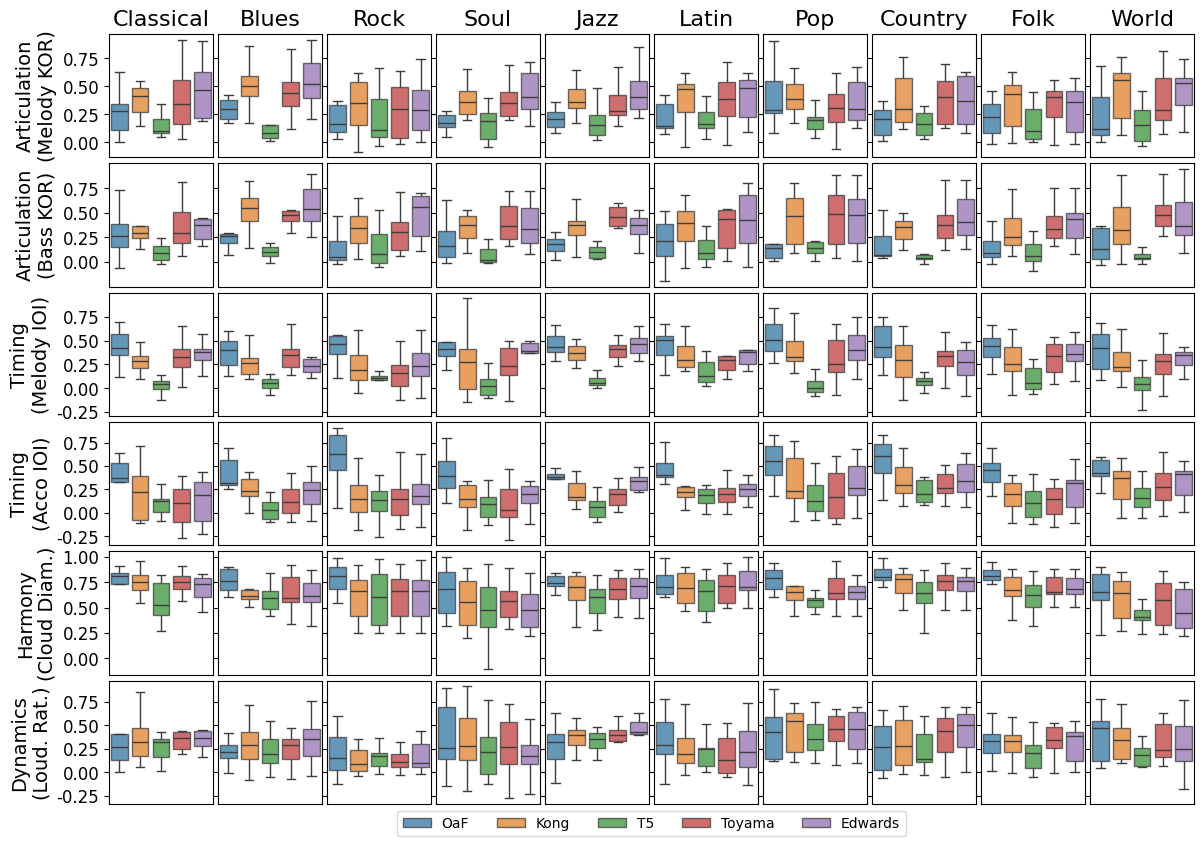

In [4]:
metrics_titles = ['Frame F1\n', 'Note F1\n(On)', 'Note F1\n(On & Off)', 'Note F1\n(On & Vel)', 'Note F1\n(On & Off & Vel)'] + \
    ['Articulation\n(Melody KOR)', 'Articulation\n(Bass KOR)', 'Articulation\n(Ratio KOR)'] + \
    ['Timing\n(Melody IOI)', 'Timing\n(Acco IOI)'] + \
    ['Harmony\n(Cloud Diam.)', 'Harmony\n(Cloud Momentum)', 'Harmony\n(Tensile Strain)'] + \
    ['Dynamics\n(Loud. Rat.)']

metric2title = dict(zip(columns_all, metrics_titles))

def overlay_means_boxplot(ax, data, metric, models_order, draw_lines=False, color='black', alpha=0.5, marker='*'):
    # Compute averages for each group
    means = data.groupby('model')[metric].mean()
    # Overlay averages as markers
    x_coords, y_coords = [], []
    for i, model in enumerate(models_order):
        if model in means:
            ax.scatter(i, means[model], color=color, alpha=alpha, marker=marker, s=50, zorder=5)
            x_coords.append(i)
            y_coords.append(means[model])
    # Connect the averages with a line
    if draw_lines:
        ax.plot(x_coords, y_coords, color=color, alpha=alpha, linestyle='--', linewidth=1, zorder=4)

PLOT_MEANS = False

fig, axs = plt.subplots(6, 10, figsize=(14, 10), sharex=True, sharey=False, gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

columns_six = columns_all[5:7] + columns_all[8:11] + [columns_all[-1]]
metrics_titles_six = metrics_titles[5:7] + metrics_titles[8:11] + [metrics_titles[-1]]

for row, (metric, metric_title) in enumerate(zip(columns_six, metrics_titles_six)):
    # Calculate the global y-axis limits for the row, excluding outliers
    row_data = []
    for model in models_order:
        model_data = df_genre[df_genre['model'] == model][metric].dropna()
        for genre in genres_order:
            genre_data = model_data[df_genre['genre'] == genre]
            q1 = genre_data.quantile(0.25)  # First quartile
            q3 = genre_data.quantile(0.75)  # Third quartile
            iqr = q3 - q1  # Interquartile range
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            filtered_data = genre_data[(genre_data >= lower_bound) & (genre_data <= upper_bound)]
            row_data.extend(filtered_data)
    y_min, y_max = min(row_data), max(row_data)
    y_margin = 0.05 * (y_max - y_min)  # Add a small margin
    y_min -= y_margin
    y_max += y_margin

    for col, genre in enumerate(genres_order):
        ax = axs[row, col]
        sns.boxplot(
            ax=ax,
            data=df_genre[df_genre['genre'] == genre],  # Filter data for the specific genre
            x='model',
            y=metric,
            hue='model',
            hue_order=models_order,
            order=models_order,
            # palette='Set3',
            legend=True,
            showfliers=False  # Hide outliers
        )
        if PLOT_MEANS:
            data = df_genre[df_genre['genre'] == genre]
            overlay_means_boxplot(ax, data, metric, models_order, marker='*') # . o * + x X p P h H 1 2 3
        for patch in ax.patches:
            patch.set_alpha(alpha)
        
        ax.set_ylim(y_min, y_max) # Set consistent y-axis limits for all subplots in the row
        
        # Set titles for the first row
        if row == 0:
            ax.set_title(genre, fontsize=fs_title)
        
        # y-axis ticks, labels, and ticklabels
        y_ticks = [i * 0.25 for i in range(-1, 5) if (i*.25 > y_min+.02 and i*.25 < y_max-.02)]
        ax.set_yticks(y_ticks) # show the same set of ticks on each subplot as the y axes are shared
        if col == 0:
            ax.set_ylabel(metric_title, fontsize=fs_axis)
            ax.set_yticklabels([f'{x:.2f}' for x in ax.get_yticks()], fontsize=fs_ticks)
        else:
            ax.set_ylabel(None)
            ax.set_yticklabels([])  # Remove y-ticks for other columns
        
        # remove x axis
        ax.set_xlabel(None)
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        # add legend
        if row == 5 and col == 4:
            ax.legend(loc='upper center', bbox_to_anchor=(1.025, 0.0), title=None, fontsize=10, ncol=len(models_order))
        else:
            ax.legend().remove()

# Adjust layout and save the figure
# fig.savefig(f'../paper/figs/eval_genre_MIMs_6x10_v2'+('a' if PLOT_MEANS else '')+'.pdf', bbox_inches='tight')
plt.show()

---

### Figure 14

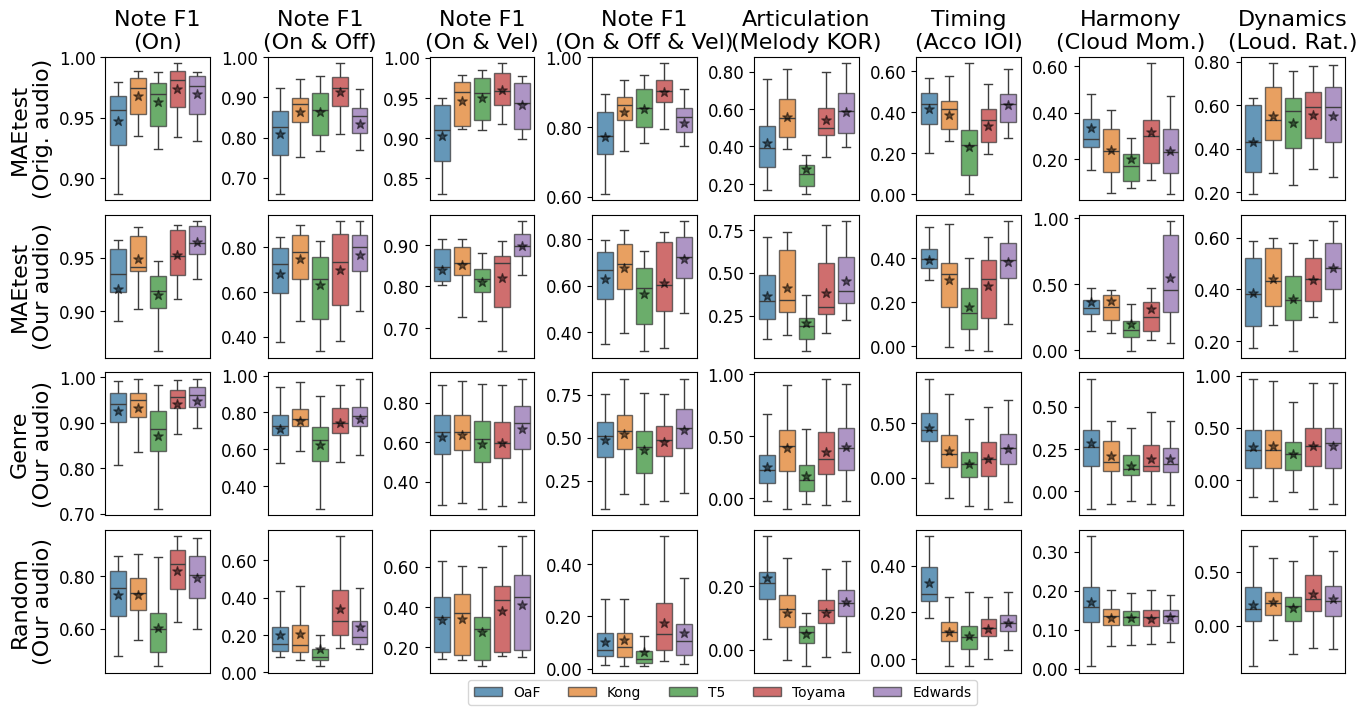

In [5]:
metrics_titles = ['Frame F1\n', 'Note F1\n(On)', 'Note F1\n(On & Off)', 'Note F1\n(On & Vel)', 'Note F1\n(On & Off & Vel)'] + \
    ['Articulation\n(Melody KOR)', 'Articulation\n(Bass KOR)', 'Articulation\n(Ratio KOR)'] + \
    ['Timing\n(Melody IOI)', 'Timing\n(Accomp IOI)'] + \
    ['Harmony\n(Cloud Diameter)', 'Harmony\n(Cloud Momentum)', 'Harmony\n(Tensile Strain)'] + \
    ['Dynamics\n(Loudness Ratio)']

metric2title = dict(zip(columns_all, metrics_titles))

def overlay_means_boxplot(ax, data, metric, models_order, draw_lines=False, color='black', alpha=0.5, marker='*'):
    # Compute averages for each group
    means = data.groupby('model')[metric].mean()
    # Overlay averages as markers
    x_coords, y_coords = [], []
    for i, model in enumerate(models_order):
        if model in means:
            ax.scatter(i, means[model], color=color, alpha=alpha, marker=marker, s=50, zorder=5)
            x_coords.append(i)
            y_coords.append(means[model])
    # Connect the averages with a line
    if draw_lines:
        ax.plot(x_coords, y_coords, color=color, alpha=alpha, linestyle='--', linewidth=1, zorder=4)

PLOT_MEANS = True

fig, axs = plt.subplots(4, 8, figsize=(8 * 2, 4 * 2), sharex=True, sharey=False, gridspec_kw={'wspace': 0.55, 'hspace': 0.10})

from itertools import product

# Generate grids for IRMs and MIMs
metric_subset_4x4_IRMs_grid = list(product(all_subsets_IRMs, columns_fscore[1:]))
metric_subset_4x4_MIMs_grid = list(product(all_subsets_MIMs, columns_4mims))

# Plot IRMs metrics (first 4 columns)
for (data, metric), ax in zip(metric_subset_4x4_IRMs_grid, axs[:, :4].reshape(-1)):
    sns.boxplot(ax=ax, data=data, x='model', y=metric, showfliers=False,
                hue='model', hue_order=models_order, legend=True,
                order=models_order)
    ax.set_ylabel(None)
    ax.legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=25)  # Rotate x tick labels
    if PLOT_MEANS:
        overlay_means_boxplot(ax, data, metric, models_order, marker='*') # . o * + x X p P h H 1 2 3
    # Set alpha for box colors
    for patch in ax.patches:
        patch.set_alpha(alpha)

# Plot MIMs metrics (last 4 columns)
for (data, metric), ax in zip(metric_subset_4x4_MIMs_grid, axs[:, 4:].reshape(-1)):
    sns.boxplot(ax=ax, data=data, x='model', y=metric, showfliers=False,
                hue='model', hue_order=models_order, legend=True,
                order=models_order)
    ax.set_ylabel(None)
    ax.legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=25)  # Rotate x tick labels
    if PLOT_MEANS:
        overlay_means_boxplot(ax, data, metric, models_order, marker='*')
    # Set alpha for box colors
    for patch in ax.patches:
        patch.set_alpha(alpha)

# Remove x-axis, ticks, and tick labels from all subplots
for ax in axs.flat:
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.set_xlabel(None)

# Set y-axis tick labels to 2 decimal places for all subplots
from matplotlib.ticker import FormatStrFormatter

for ax in axs.flat:
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(axis='y', labelsize=fs_ticks)

# Set column titles for IRMs metrics
axs[0][0].set_title('Note F1\n(On)', fontsize=fs_title)
axs[0][1].set_title('Note F1\n(On & Off)', fontsize=fs_title)
axs[0][2].set_title('Note F1\n(On & Vel)', fontsize=fs_title)
axs[0][3].set_title('Note F1\n(On & Off & Vel)', fontsize=fs_title)

# Set column titles for MIMs metrics
axs[0][4].set_title('Articulation\n(Melody KOR)', fontsize=fs_title)
axs[0][5].set_title('Timing\n(Acco IOI)', fontsize=fs_title)
axs[0][6].set_title('Harmony\n(Cloud Mom.)', fontsize=fs_title)
axs[0][7].set_title('Dynamics\n(Loud. Rat.)', fontsize=fs_title)

# Set row labels for datasets
axs[0][0].set_ylabel('MAEtest\n(Orig. audio)', fontsize=fs_title) # fontweight='bold', fontfamily='serif',
axs[1][0].set_ylabel('MAEtest\n(Our audio)', fontsize=fs_title)
axs[2][0].set_ylabel('Genre\n(Our audio)', fontsize=fs_title)
axs[3][0].set_ylabel('Random\n(Our audio)', fontsize=fs_title)

# add legend
axs[3,3].legend(loc='upper center', bbox_to_anchor=(1.25, 0.0), title=None, ncol=len(models_order))

# fig.savefig(f'../paper/figs/eval_grid_data_metrics_rel_mod_perf{"_means" if PLOT_MEANS else ""}.pdf', bbox_inches='tight')
plt.show()

---

### Figures 9-10

In [6]:
metrics_titles = ['Frame F1', 'Note F1 (On)', 'Note F1 (On & Off)', 'Note F1 (On & Vel)', 'Note F1 (On & Off & Vel)'] + \
    ['Articulation\n(Melody KOR)', 'Articulation\n(Bass KOR)', 'Articulation (Ratio KOR)'] + \
    ['Timing\n(Melody IOI)', 'Timing\n(Accompaniment IOI)'] + \
    ['Harmony\n(Cloud Diameter)', 'Harmony\n(Cloud Momentum)', 'Harmony\n(Tensile Strain)'] + \
    ['Dynamics\n(Loudness Ratio)']

#### breakdown into 2 figures

1. Note-level IR metrics
2. MI metrics

In [7]:
# Add 'data' column to distinguish datasets
df_maetest['data'] = df_maetest['audioset'].map({'maestro': 'MAEtest (MAE)', 'disklavier': 'MAEtest (DK)'})
df_genre['data'] = 'Genre (DK)'
# Align columns (ensure both DataFrames have the same structure)
df_combined = pd.concat([df_maetest, df_genre], ignore_index=True)
df_maetest = df_maetest.drop(columns=['data'])
df_genre = df_genre.drop(columns=['data'])

assert isinstance(df_combined, pd.DataFrame)
from matplotlib.ticker import FuncFormatter

def overlay_means_boxplot(ax, data, metric, models_order, draw_lines=False, draw_marks=True,
    linestyle='-', linecolor='goldenrod', linealpha=1.0, linewidth=1.0, marker='x', markcolor='goldenrod', markalpha=1.0):
    # Compute averages for each group (model and data)
    means = data.groupby(['model', 'data'])[metric].mean()
    # Overlay averages as markers
    x_coords, y_coords = {}, {}
    for i, model in enumerate(models_order):
        for j, dataset in enumerate(data['data'].unique()):
            if (model, dataset) in means:
                # Adjust x-coordinate for triplets (datasets)
                x = i + (j - 1) * 0.27  # Spread triplets slightly around the x-coordinate
                if draw_marks:
                    ax.scatter(x, means[(model, dataset)], marker=marker, color=markcolor, alpha=markalpha, s=50, zorder=5)
                x_coords.setdefault(model, []).append(x)
                y_coords.setdefault(model, []).append(means[(model, dataset)])
    # Connect the averages with a line across the triplets for each model
    if draw_lines:
        for model in x_coords:
            ax.plot(x_coords[model], y_coords[model], marker=marker, linestyle=linestyle, color=linecolor, alpha=linealpha, linewidth=linewidth, zorder=4)

PLOT_MEANS = True

columns_subset = columns_all[1:7] + columns_all[8:]
metrics_titles_subset = metrics_titles[1:7] + metrics_titles[8:]

### Figure 9

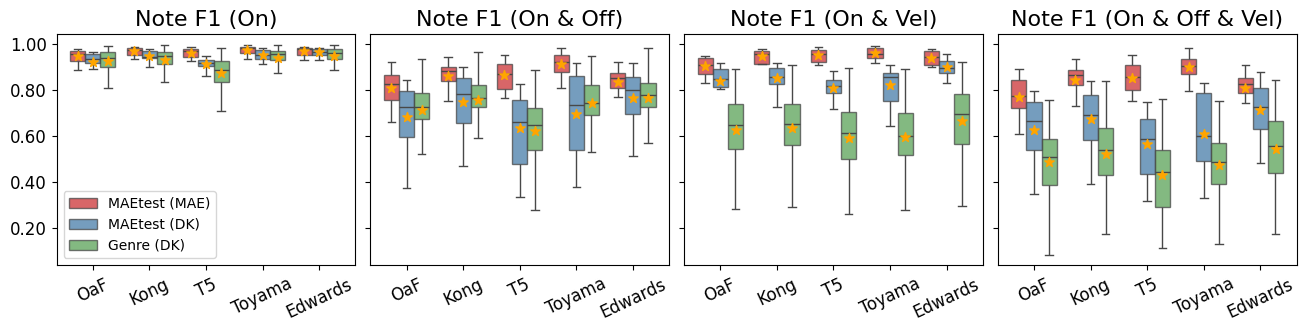

In [8]:
# IRMs
fig, axs = plt.subplots(1, 4, figsize=(16, 3), sharex=True, sharey=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.35})
for metric, metric_title, ax in zip(columns_subset[:4], metrics_titles_subset[:4], axs.reshape(-1)):
    sns.boxplot(
        ax=ax, data=df_combined, x='model', y=metric, hue='data', showfliers=False, 
        order=models_order, palette='Set1'
    )
    if PLOT_MEANS:
        overlay_means_boxplot(ax, df_combined, metric, models_order, marker='*', markcolor='orange')
    for patch in ax.patches:
        patch.set_alpha(alpha)
    ax.set_title(metric_title, fontsize=fs_title)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    plt.setp(ax.get_xticklabels(), rotation=25)  # Rotate x tick labels
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))  # Format y-axis tick labels
    ax.tick_params(axis='x', labelsize=fs_ticks)
    ax.tick_params(axis='y', labelsize=fs_ticks)
    if metric == columns_subset[0]:
        ax.legend(loc='lower left')
    else:
        ax.legend().remove()

# fig.savefig(f'../paper/figs/eval_sds_mds_combo_IRMs{"_means" if PLOT_MEANS else ""}.pdf', bbox_inches='tight')
plt.show()

### Figure 10

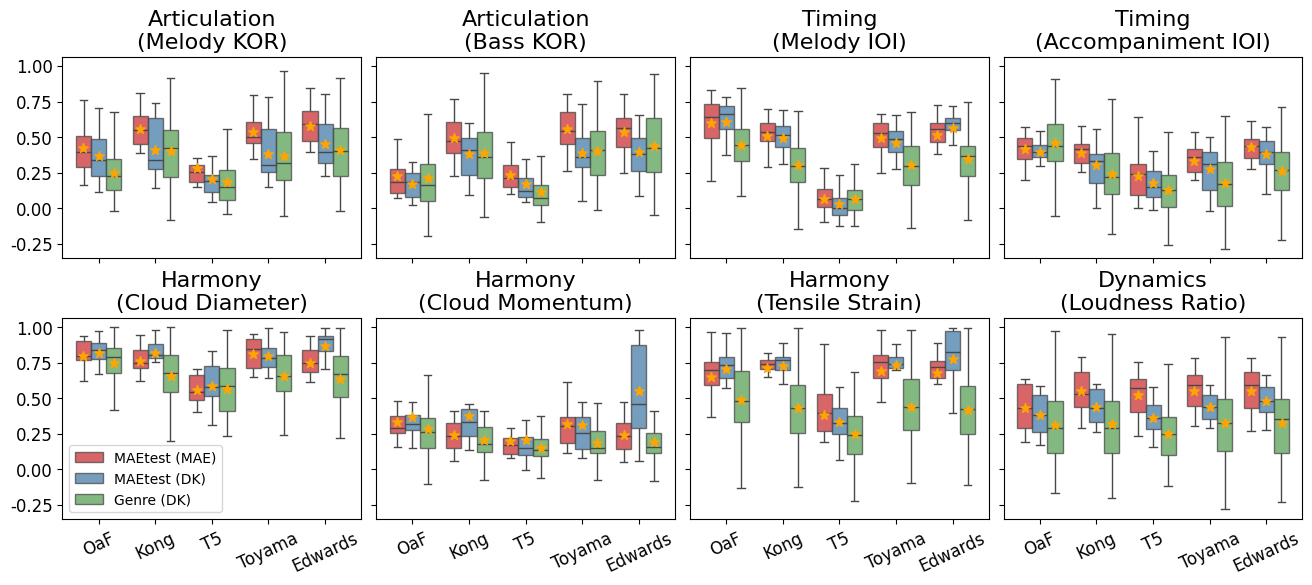

In [9]:
# MIMs
fig, axs = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.30})
for metric, metric_title, ax in zip(columns_subset[4:], metrics_titles_subset[4:], axs.reshape(-1)):
    sns.boxplot(
        ax=ax, data=df_combined, x='model', y=metric, hue='data', showfliers=False, 
        order=models_order, palette='Set1'
    )
    if PLOT_MEANS:
        overlay_means_boxplot(ax, df_combined, metric, models_order, marker='*', markcolor='orange')
    for patch in ax.patches:
        patch.set_alpha(alpha)
    ax.set_title(metric_title, fontsize=fs_title)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    plt.setp(ax.get_xticklabels(), rotation=25)  # Rotate x tick labels
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))  # Format y-axis tick labels
    ax.tick_params(axis='x', labelsize=fs_ticks)
    ax.tick_params(axis='y', labelsize=fs_ticks)
    if metric == columns_subset[8]:
        ax.legend(loc='lower left')
    else:
        ax.legend().remove()

# fig.savefig(f'../paper/figs/eval_sds_mds_combo_MIMs{"_means" if PLOT_MEANS else ""}.pdf', bbox_inches='tight')
plt.show()

# END